<a href="https://colab.research.google.com/github/aswinss949/ICT-BATCH-9/blob/main/Case_Study_on_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##libraries


In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder



reading dataset

In [152]:
filepath = '/content/House_Pricing.csv'

In [153]:
customer_df = pd.read_csv(filepath)
customer_df.head(2)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


## exploring the data

In [154]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [155]:
customer_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## exploring the data

## exploring the data

In [156]:
customer_df.isna()


,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [157]:
customer_df.isnull()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [158]:
customer_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [159]:
missing_percent = customer_df.isna().sum()/len(customer_df)
missing_percent.sort_values(ascending=True)

,0
ID,0.000000
Date House was Sold,0.000000
No of Bedrooms,0.000000
No of Floors,0.000000
Basement Area (in Sqft),0.000000
Overall Grade,0.000000
Condition of the House,0.000000
Waterfront View,0.000000
Renovated Year,0.000000
Age of House (in Years),0.000000


In [160]:
num_cols=customer_df.select_dtypes(include=['number'])
cat_cols=customer_df.select_dtypes(include=['object'])

In [161]:
num_cols

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530.0,1131.0,3.0,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,400000.0,4,2.50,2310.0,5813.0,2.0,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,402101.0,2,0.75,1020.0,1350.0,2.0,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,400000.0,3,2.50,1600.0,2388.0,2.0,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [162]:
num_cols=customer_df.select_dtypes(include=['number']).columns
cat_cols=customer_df.select_dtypes(include=['object']).columns

In [163]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [164]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

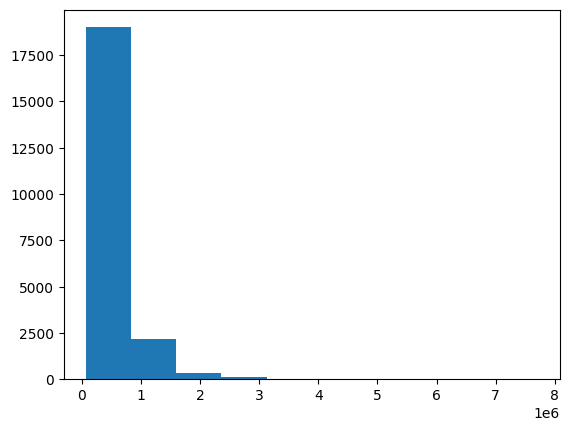

In [165]:
plt.hist(customer_df['Sale Price'])
plt.show()

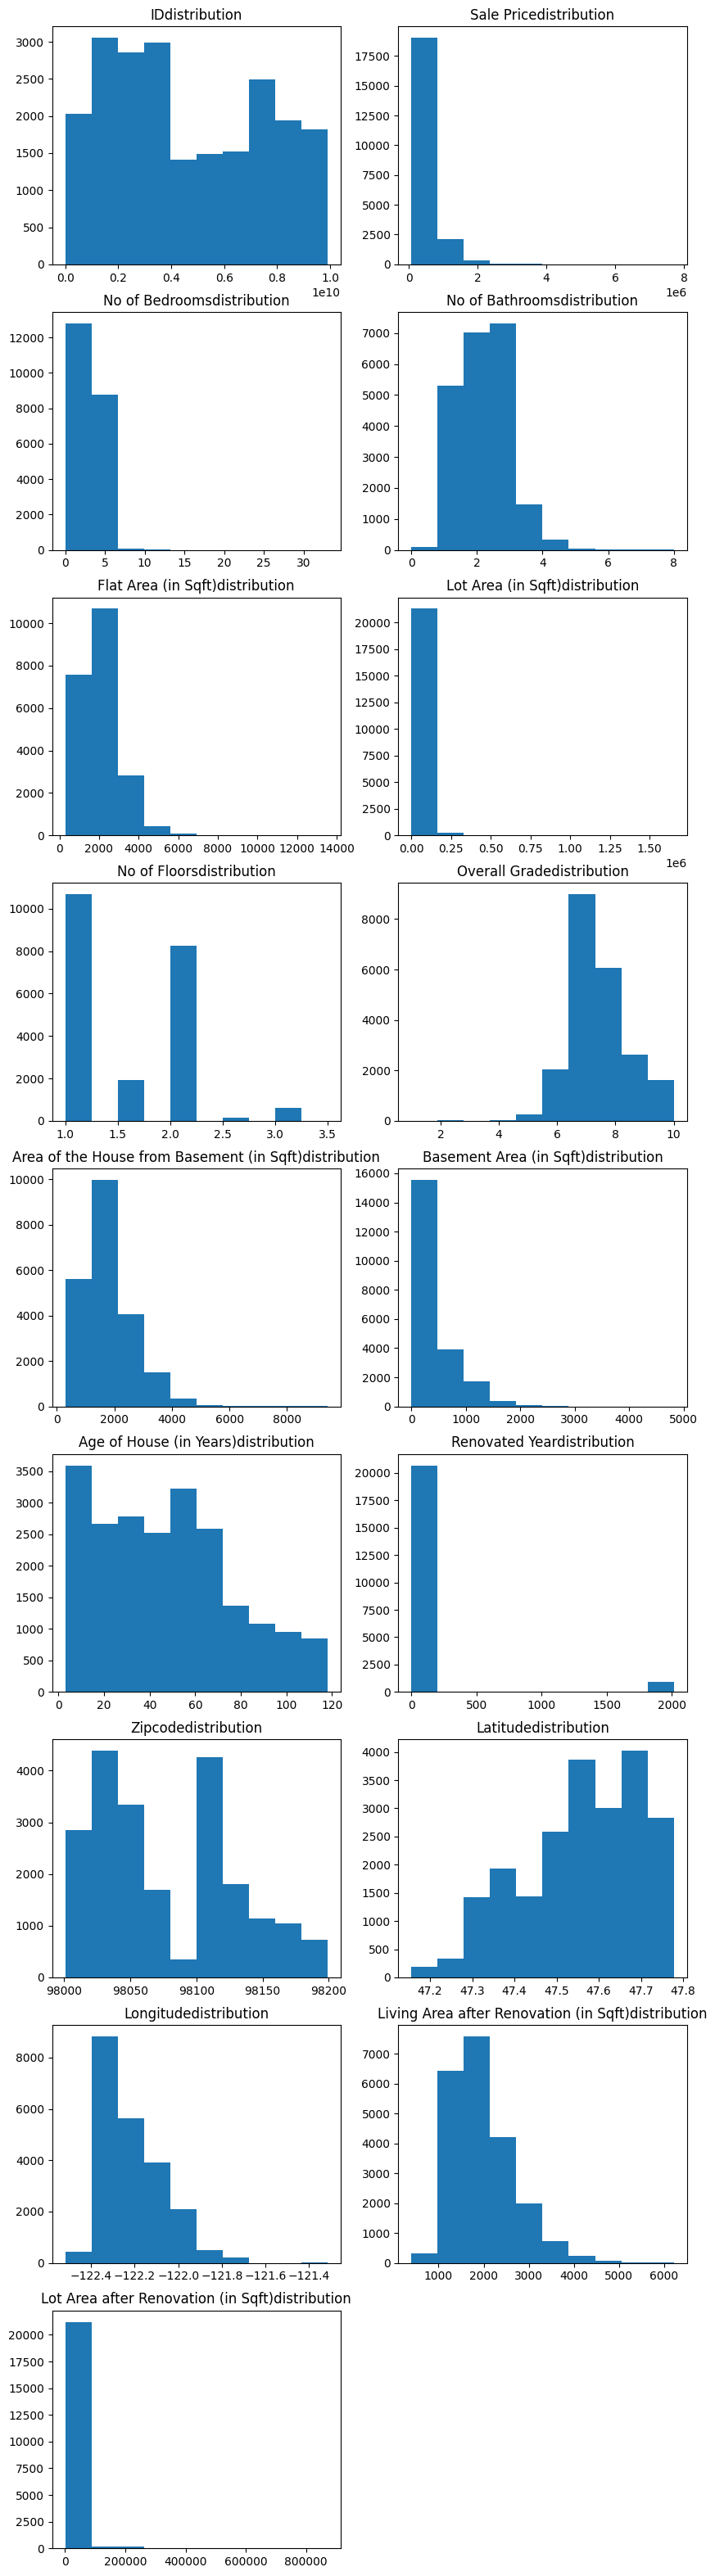

In [166]:
plt.figure(figsize=(10,40))
for i,col in enumerate(num_cols,1):
  plt.subplot(9, 2,i)
  plt.hist(customer_df[col])
  plt.title(col+'distribution')
  plt.tight_layout

plt.show()

In [167]:
customer_df['Sale Price'].fillna(customer_df['Sale Price'].median(),inplace=True)

customer_df['No of Bathrooms'].fillna(customer_df['No of Bathrooms'].median(),inplace=True)
customer_df['Flat Area (in Sqft)'].fillna(customer_df['Flat Area (in Sqft)'].median(),inplace=True)
customer_df['Lot Area (in Sqft)'].fillna(customer_df['Lot Area (in Sqft)'].median(),inplace=True)

customer_df['Area of the House from Basement (in Sqft)'].fillna(customer_df['Area of the House from Basement (in Sqft)'].median(),inplace=True)
customer_df['Zipcode'].fillna(customer_df['Zipcode'].median(),inplace=True)
customer_df['Latitude'].fillna(customer_df['Latitude'].median(),inplace=True)
customer_df['Longitude'].fillna(customer_df['Longitude'].median(),inplace=True)
customer_df['Living Area after Renovation (in Sqft)'].fillna(customer_df['Living Area after Renovation (in Sqft)'].median(),inplace=True)
customer_df.isna().sum()

/tmp/ipykernel_7743/2099626953.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Sale Price'].fillna(customer_df['Sale Price'].median(),inplace=True)
/tmp/ipykernel_7743/2099626953.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489


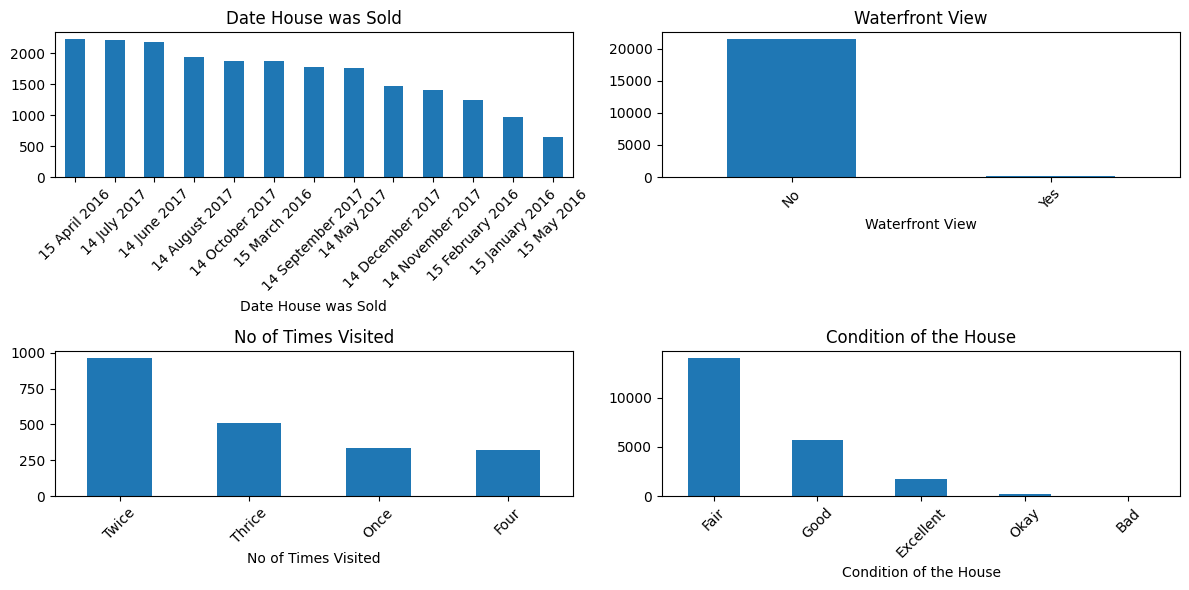

In [168]:
import math

#plot to understand categorical value distribution
num_cat_cols = len(cat_cols)
n_cols = 2  # Display 2 plots per row
n_rows = math.ceil(num_cat_cols / n_cols) # Calculate the number of rows needed

plt.figure(figsize=(12, 6))

for i,col in enumerate(cat_cols,1):
  plt.subplot(n_rows, n_cols, i)
  customer_df[col].value_counts().plot(kind = 'bar')
  plt.title(col)
  plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

In [169]:
customer_df.dropna(axis=0,inplace=True)

In [170]:
customer_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,0


In [171]:
customer_df['ID'].unique()

array([9297300055, 2524049179,  822039084, ..., 7011201004, 8672200110,
       8956200760])

In [172]:
customer_df['Sale Price'].unique()

array([ 650000., 2000000., 1350000.,  951000.,  437500.,  329950.,
        480000.,  660000.,  445000., 2250000.,  269950., 1100000.,
       1510000., 1070000.,  655000.,  472000., 2400000.,  592500.,
        369900., 2900000., 2050000.,  630000.,  550000.,  267500.,
       3080000.,  834000., 2380000., 1380000., 1400000.,  295000.,
        679900.,  795000., 1120000.,  840000.,  339000.,  578000.,
       1450000.,  705000., 1200000.,  460000.,  590000.,  525000.,
       1280000.,  370000.,  299000., 1600000., 2130000.,  725000.,
       1950000.,  930000.,  730000.,  595000., 1040000.,  729500.,
        325000., 1000000., 3070000.,  865000.,  478500.,  373000.,
        700000.,  530000.,  501000.,  517500.,  950000.,  942500.,
       1310000., 1360000., 1220000.,  662500.,  285000.,  425000.,
        839900.,  451000.,  990000.,  570000.,  720000.,  335000.,
        397500.,  645000., 2450000.,  768000.,  980000.,  512031.,
        935000.,  790000.,  318000., 1240000.,  986000.,  8250

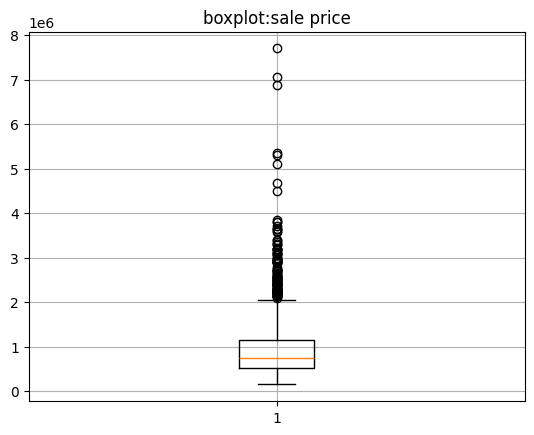

In [173]:
plt.boxplot(customer_df['Sale Price'])
plt.title('boxplot:sale price')
plt.grid()
plt.show()

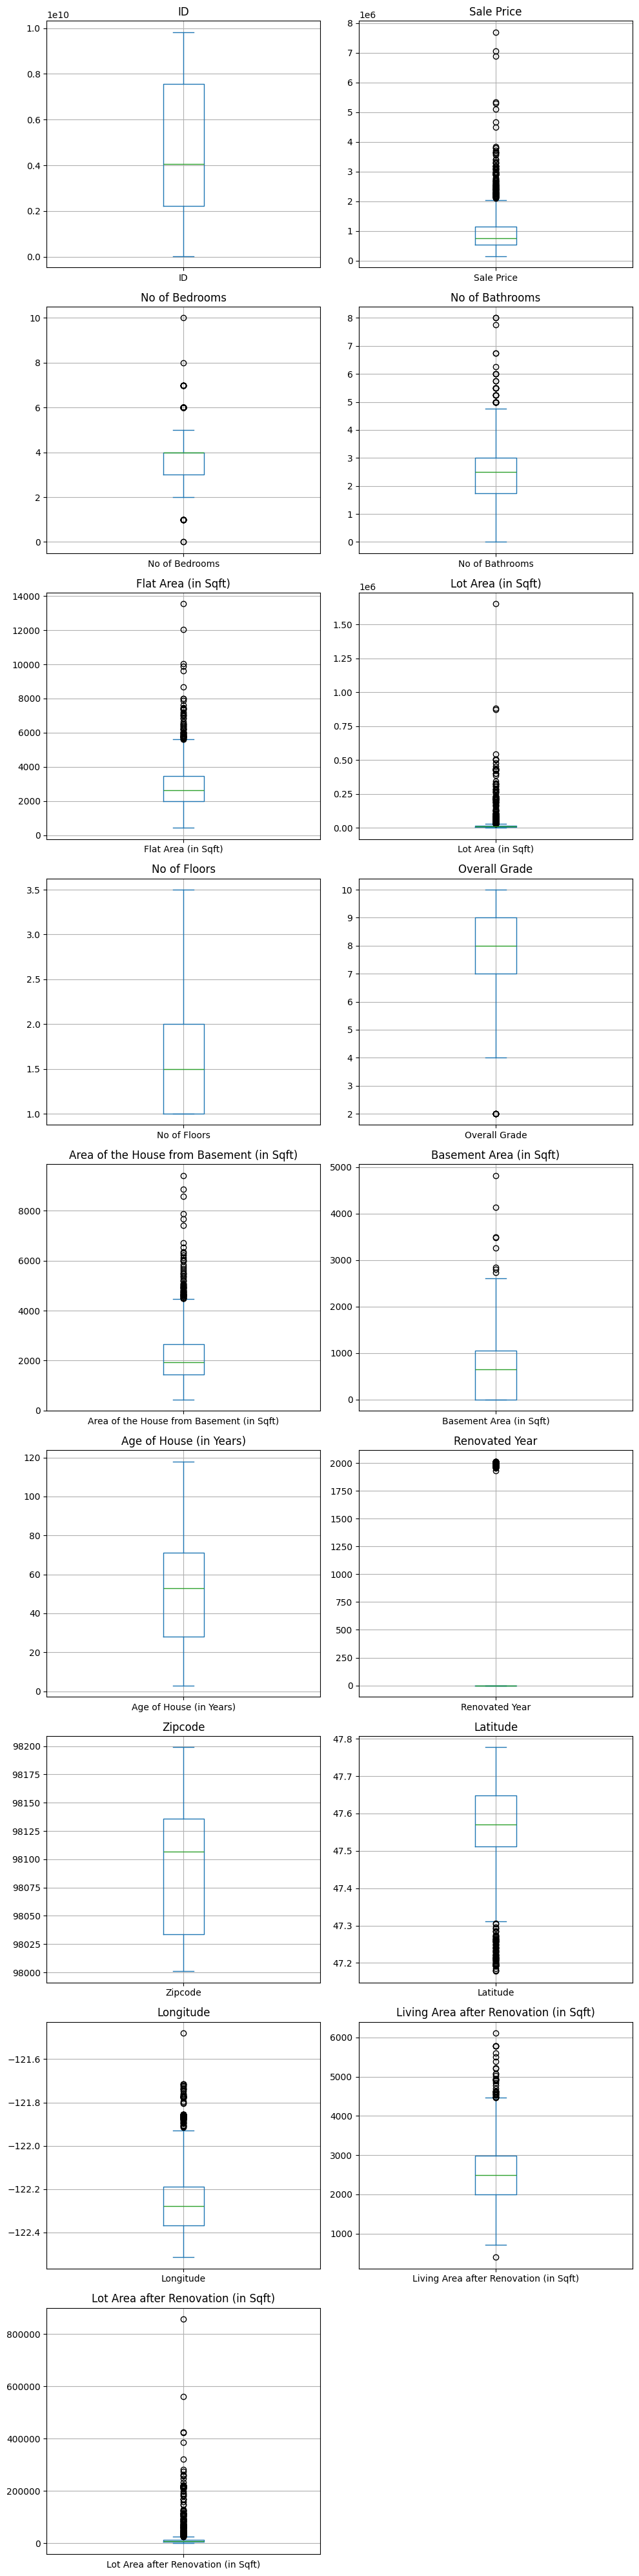

In [174]:
plt.figure(figsize=(10,40))
for i, col in enumerate (num_cols, 1):
  plt.subplot(9,2,i)
  customer_df[col].plot(kind='box')
  plt.title(col)
  plt.grid()

plt.tight_layout()

In [175]:
Q1 = customer_df[num_cols].quantile(0.25)
Q3 = customer_df[num_cols].quantile(0.75)
IQR = Q3 -Q1

upper_limit = Q3 + (1.5*IQR)
lower_limit = Q1 - (1.5*IQR)

outliers =((customer_df[num_cols] > upper_limit)|(customer_df[num_cols] < lower_limit))

In [176]:
Q1 = customer_df[num_cols].quantile(0.25)
Q3 = customer_df[num_cols].quantile(0.75)
IQR = Q3 -Q1

upper_limit = Q3 + (1.5*IQR)
lower_limit = Q1 - (1.5*IQR)

outliers =((customer_df[num_cols] > upper_limit)|(customer_df[num_cols] < lower_limit)).any(axis=1)

outliers_df = customer_df[outliers]
outliers_df

outlier_percentage = len(outliers_df)*100/len(customer_df)
print('percentage of outliers in the dataframe :',outlier_percentage)

percentage of outliers in the dataframe : 32.580037664783426


In [177]:
outliers

,0
15,False
21,True
49,True
58,False
60,False
...,...
21554,False
21576,True
21579,False
21593,False


In [178]:
customer_df = customer_df[~outliers]

In [179]:
customer_df.shape

(1432, 21)

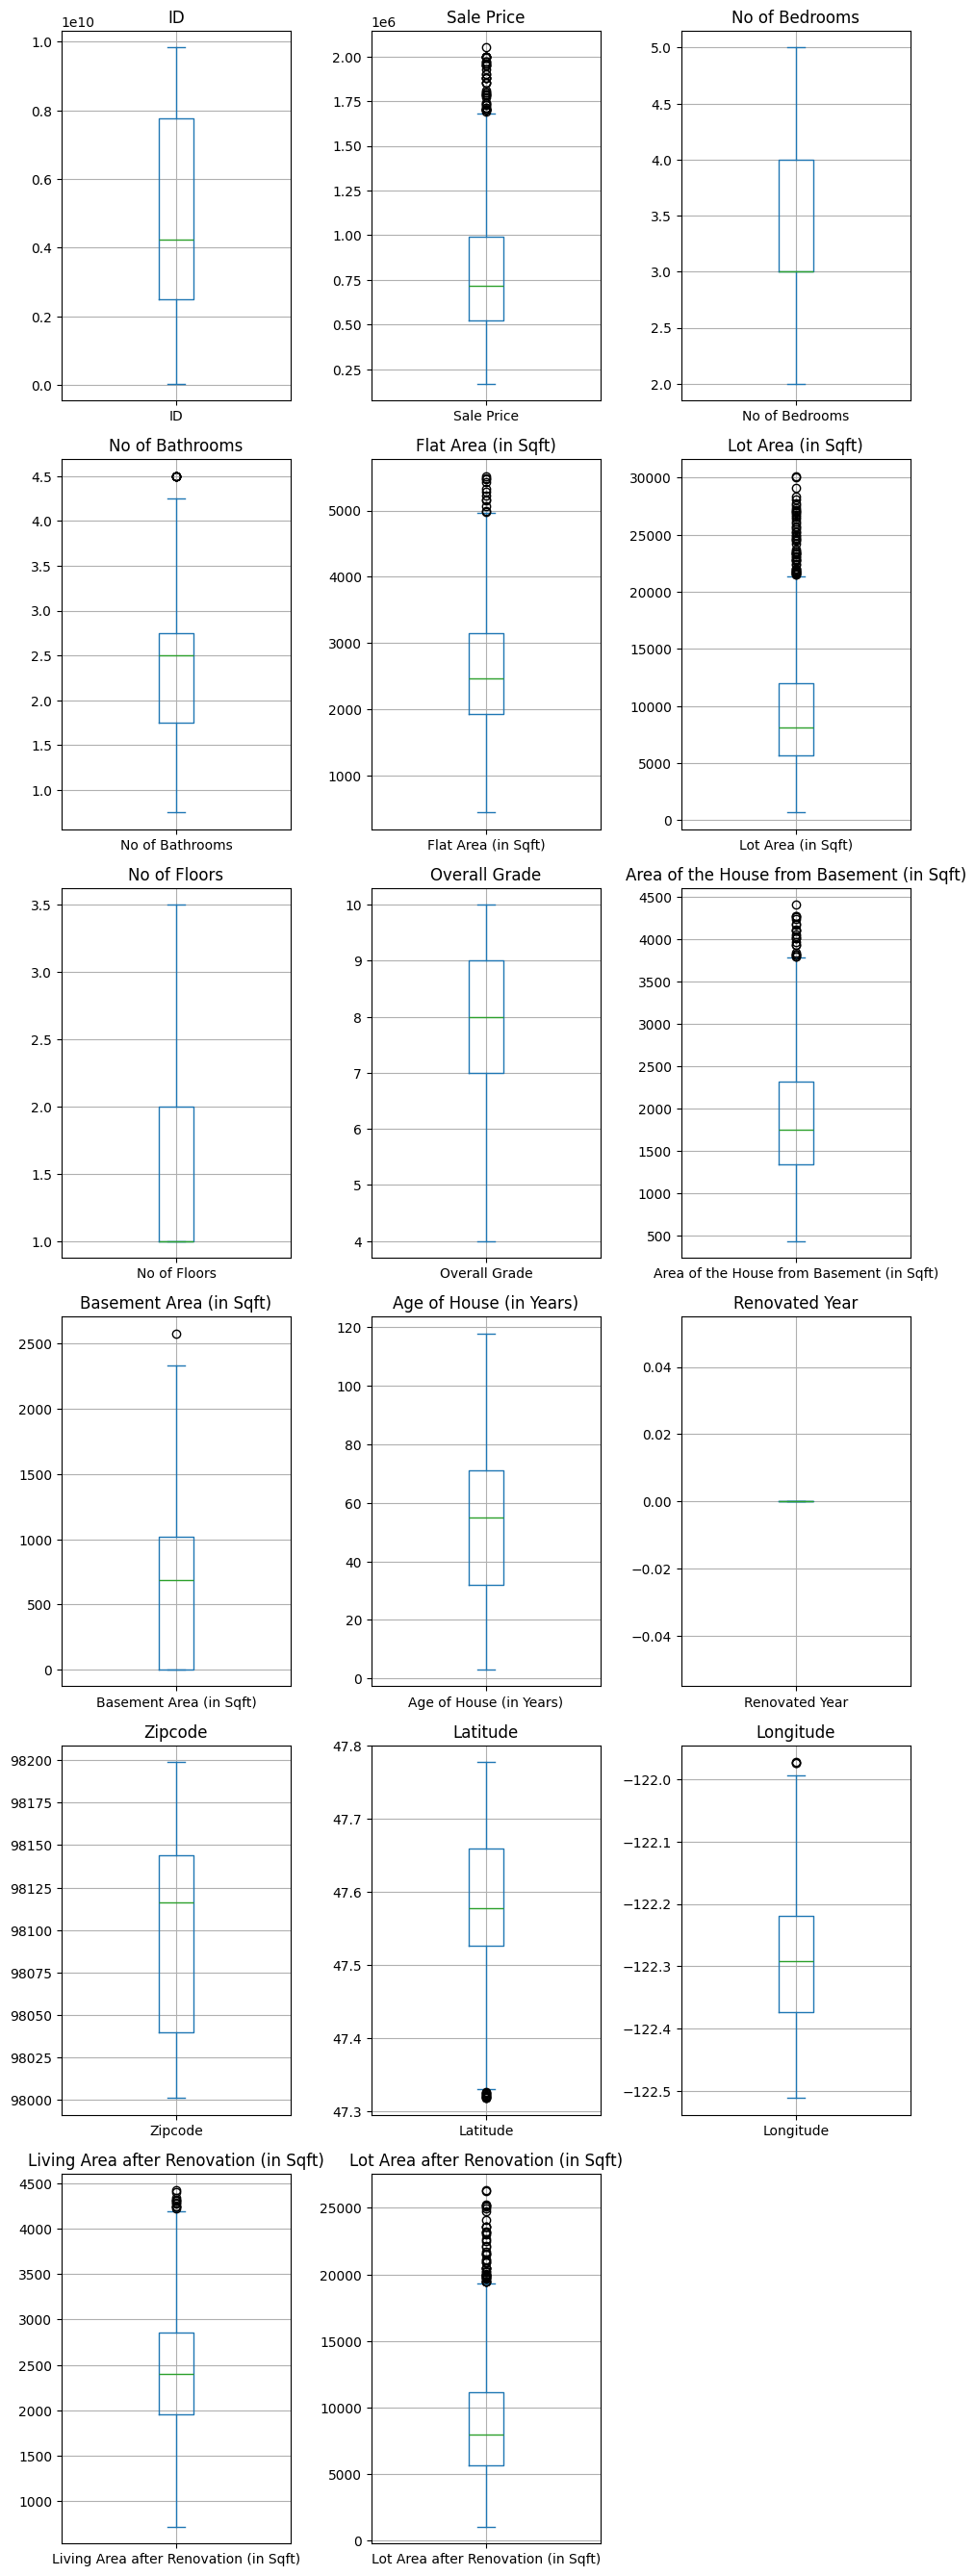

In [180]:
plt.figure(figsize=(10,40))
for i, col in enumerate (num_cols, 1):
  plt.subplot(9,3,i)
  customer_df[col].plot(kind='box')
  plt.title(col)
  plt.grid()

plt.tight_layout()

#scaling

In [181]:
customer_df.duplicated().sum()

np.int64(0)

In [182]:
customer_df.drop_duplicates(inplace=True)
customer_df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
15,9297300055,15 January 2016,650000.0,4,3.00,2950.0,5000.0,2.0,No,Thrice,...,9,1980.0,970,39,0,98126.0,47.5714,-122.375,2140.0,4000
58,7922800400,14 August 2017,951000.0,5,3.25,3250.0,14342.0,2.0,No,Four,...,8,3250.0,0,50,0,98008.0,47.5880,-122.116,2960.0,11044
60,1516000055,14 December 2017,650000.0,3,2.25,2150.0,21235.0,1.0,No,Thrice,...,8,1590.0,560,59,0,98166.0,47.4336,-122.339,2570.0,18900
113,6126500060,14 November 2017,329950.0,3,1.75,2080.0,5969.0,1.0,No,Twice,...,7,1080.0,1000,47,0,98108.0,47.5474,-122.295,2090.0,5500
114,8961960160,14 October 2017,480000.0,4,2.50,3230.0,16171.0,2.0,No,Thrice,...,9,2520.0,710,17,0,98001.0,47.3183,-122.253,2640.0,8517


In [183]:
corr_matrix = customer_df[num_cols].corr(method='pearson')
corr_matrix

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,-0.082118,0.012161,0.003278,-0.022679,0.004948,-0.000615,-0.027151,0.015772,-0.057377,-0.075714,NaN,-0.111650,-0.035072,0.139548,-0.031501,-0.023989
Sale Price,-0.082118,1.000000,0.233852,0.469773,0.617373,0.191663,0.279500,0.638789,0.553338,0.275356,-0.177486,NaN,-0.210439,0.297717,0.180945,0.573538,0.199474
No of Bedrooms,0.012161,0.233852,1.000000,0.488950,0.541376,0.189833,0.091920,0.325928,0.383796,0.377701,-0.244524,NaN,-0.186728,-0.030883,0.250416,0.337026,0.184064
No of Bathrooms,0.003278,0.469773,0.488950,1.000000,0.725707,0.154266,0.427733,0.615888,0.632224,0.347895,-0.546095,NaN,-0.230450,0.024317,0.273440,0.445510,0.147842
Flat Area (in Sqft),-0.022679,0.617373,0.541376,0.725707,1.000000,0.330510,0.279564,0.724327,0.795376,0.581371,-0.458042,NaN,-0.269886,0.018282,0.315860,0.658254,0.317859
Lot Area (in Sqft),0.004948,0.191663,0.189833,0.154266,0.330510,1.000000,-0.168516,0.260256,0.273853,0.177247,-0.148100,NaN,-0.226886,-0.179688,0.226948,0.419901,0.816380
No of Floors,-0.000615,0.279500,0.091920,0.427733,0.279564,-0.168516,1.000000,0.400943,0.556128,-0.286010,-0.375641,NaN,-0.061920,0.067955,0.074661,0.101377,-0.142055
Overall Grade,-0.027151,0.638789,0.325928,0.615888,0.724327,0.260256,0.400943,1.000000,0.708950,0.242644,-0.534944,NaN,-0.269571,0.085551,0.258641,0.625855,0.262542
Area of the House from Basement (in Sqft),0.015772,0.553338,0.383796,0.632224,0.795376,0.273853,0.556128,0.708950,1.000000,-0.030373,-0.493851,NaN,-0.265727,0.003769,0.346072,0.576887,0.268716
Basement Area (in Sqft),-0.057377,0.275356,0.377701,0.347895,0.581371,0.177247,-0.286010,0.242644,-0.030373,1.000000,-0.092440,NaN,-0.088162,0.024683,0.055755,0.310921,0.163258


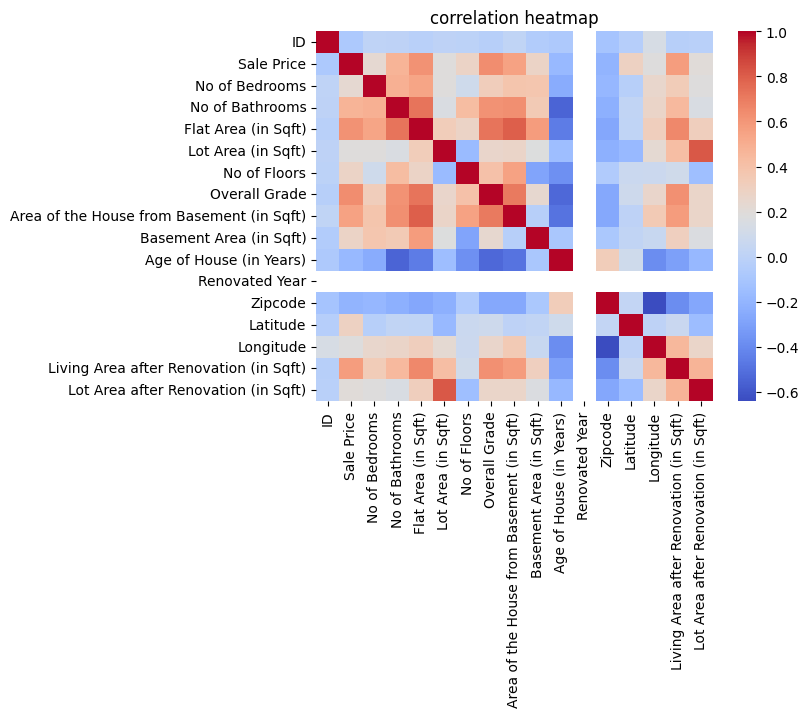

In [184]:
sns.heatmap(corr_matrix,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [185]:
customer_df.drop(['Renovated Year' ,'ID','Zipcode','Latitude','Longitude'],axis = 1,inplace=True)
customer_df.head(2)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
15,15 January 2016,650000.0,4,3.00,2950.0,5000.0,2.0,No,Thrice,Fair,9,1980.0,970,39,2140.0,4000
58,14 August 2017,951000.0,5,3.25,3250.0,14342.0,2.0,No,Four,Good,8,3250.0,0,50,2960.0,11044


In [186]:
num_cols = customer_df.select_dtypes(include=['number']).columns
num_cols

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

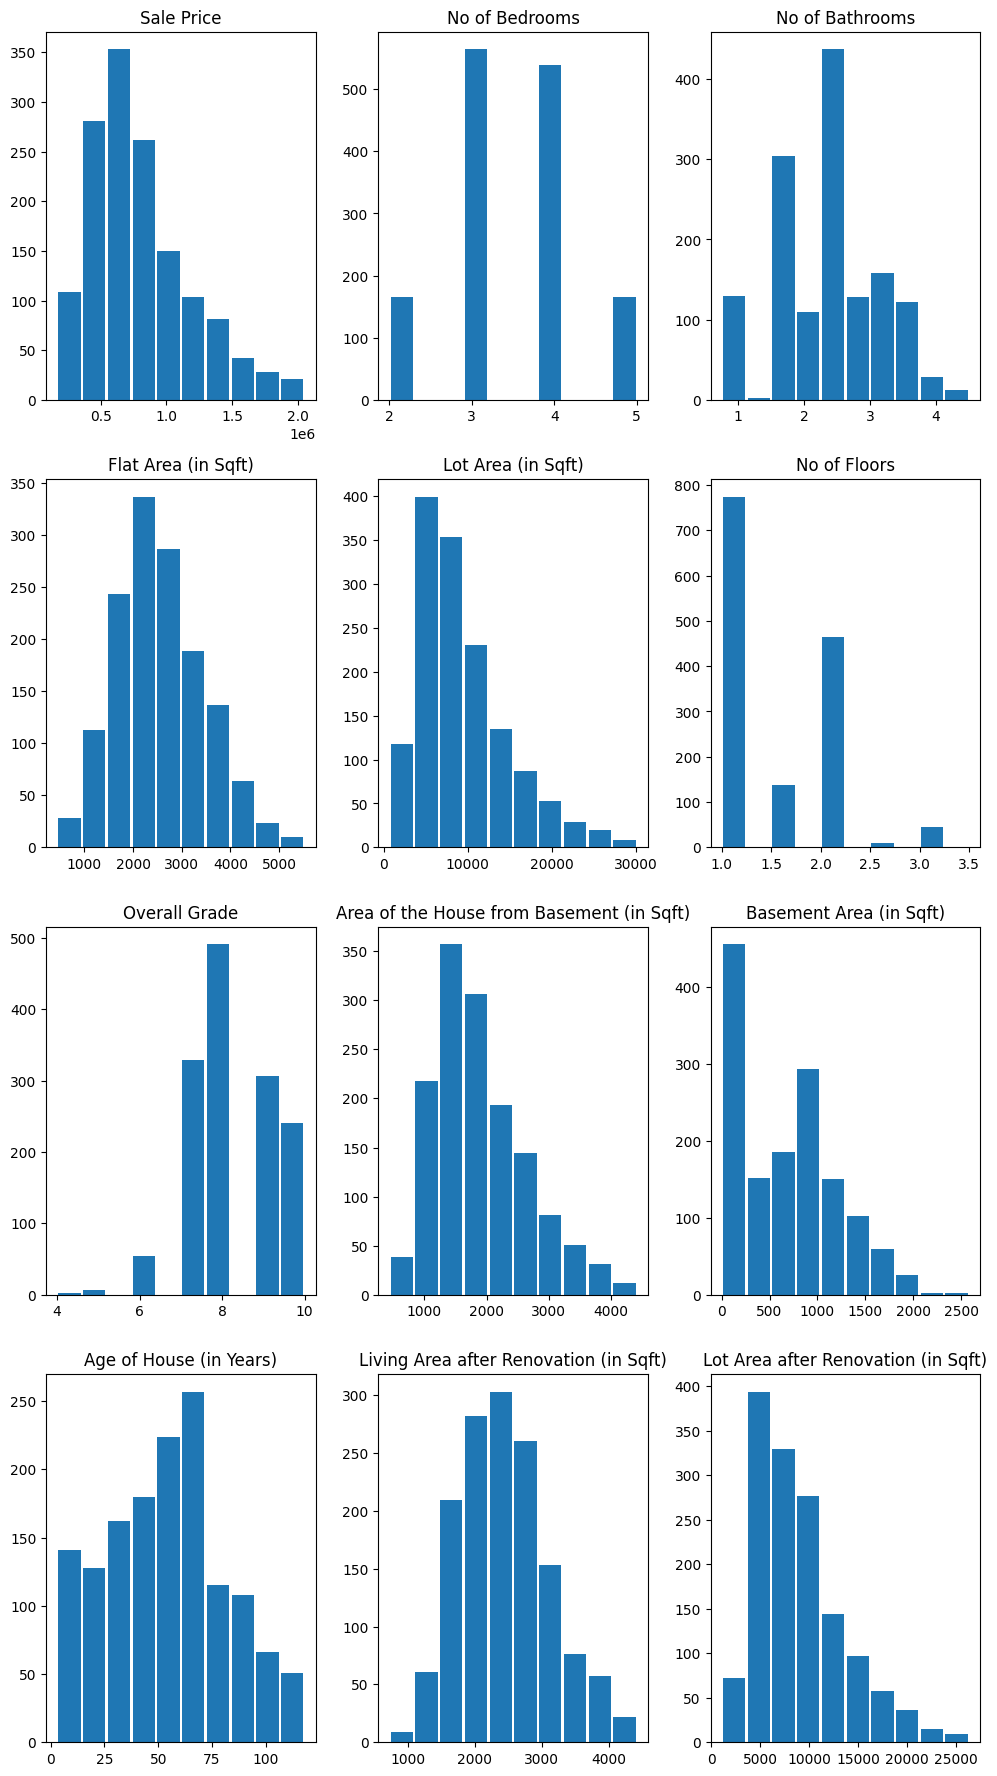

In [187]:
plt.figure(figsize=(10,40))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,3,i)
  plt.hist(customer_df[col],rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

#scaling

In [188]:
min_max_scaler= MinMaxScaler()
customer_df[['No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)']]= min_max_scaler.fit_transform(customer_df[['No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)']])

In [189]:
customer_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,1.432000e+03,1432.000000,1432.000000,1432.000000,1432.000000,1432.000000,1432.000000,1432.000000,1432.000000,1432.000000,1432.000000,1432.000000
mean,7.997328e+05,0.496974,0.425978,0.416047,0.295821,0.179330,0.704027,0.367759,0.253481,0.440412,0.465463,0.312219
std,3.756367e+05,0.281130,0.198953,0.177650,0.180564,0.217521,0.189146,0.184935,0.211935,0.240823,0.179369,0.179119
min,1.693170e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.250000e+05,0.333333,0.266667,0.291339,0.170299,0.000000,0.500000,0.226700,0.000000,0.252174,0.334459,0.183874
50%,7.190000e+05,0.333333,0.466667,0.397638,0.251767,0.000000,0.666667,0.329975,0.265504,0.452174,0.454054,0.273276
75%,9.900000e+05,0.666667,0.533333,0.531496,0.384369,0.400000,0.833333,0.474181,0.395349,0.591304,0.578378,0.400548
max,2.050000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


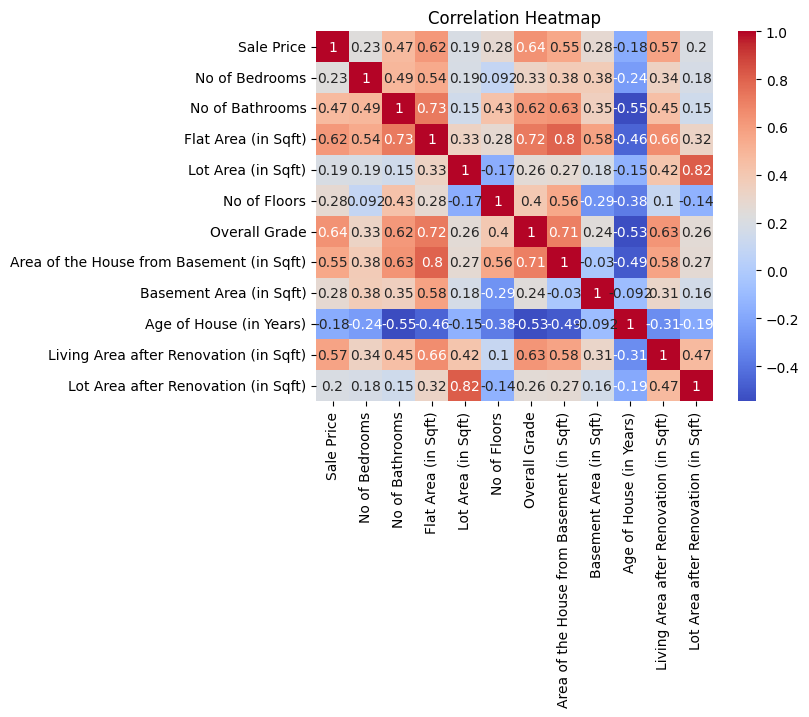

In [190]:
corr_matrix= customer_df[num_cols].corr(method='pearson')
corr_matrix

sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [191]:
customer_df.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
15,15 January 2016,650000.0,0.666667,0.600000,0.494094,0.146439,0.4,No,Thrice,Fair,0.833333,0.387909,0.375969,0.313043,0.383784,0.116550
58,14 August 2017,951000.0,1.000000,0.666667,0.553150,0.463849,0.4,No,Four,Good,0.666667,0.707809,0.000000,0.408696,0.605405,0.395509
60,14 December 2017,650000.0,0.333333,0.400000,0.336614,0.698050,0.0,No,Thrice,Good,0.666667,0.289673,0.217054,0.486957,0.500000,0.706625
113,14 November 2017,329950.0,0.333333,0.266667,0.322835,0.179363,0.0,No,Twice,Fair,0.500000,0.161209,0.387597,0.382609,0.370270,0.175953
114,14 October 2017,480000.0,0.666667,0.466667,0.549213,0.525992,0.4,No,Thrice,Fair,0.833333,0.523929,0.275194,0.121739,0.518919,0.295434


In [192]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

In [193]:
unique_values = customer_df['Date House was Sold'].unique()
print(unique_values)

['15 January 2016' '14 August 2017' '14 December 2017' '14 November 2017'
 '14 October 2017' '14 July 2017' '14 May 2017' '15 February 2016'
 '14 June 2017' '14 September 2017' '15 April 2016' '15 May 2016'
 '15 March 2016']


In [194]:
unique_values = customer_df['Waterfront View'].unique()
print(unique_values)

['No' 'Yes']


In [195]:
unique_values = customer_df['No of Times Visited'].unique()
print(unique_values)

['Thrice' 'Four' 'Twice' 'Once']


In [196]:
unique_values = customer_df['Condition of the House'].unique()
print(unique_values)

['Fair' 'Good' 'Excellent' 'Okay' 'Bad']


In [202]:
label_encoder= LabelEncoder()
customer_df['Waterfront View']=label_encoder.fit_transform(customer_df['Waterfront View'])
customer_df['Condition of the House']=label_encoder.fit_transform(customer_df['Condition of the House'])

In [204]:
mapping = {
    "Poor": 0,
    "Fair": 1,
    "Average": 2,
    "Good": 3,
    "Excellent": 4
}

customer_df['Condition of the House'] = customer_df['Condition of the House'].map(mapping)

### Target Variable and Data Splitting

In [197]:
from sklearn.model_selection import train_test_split

y = customer_df['Sale Price']

X = customer_df.drop('Sale Price', axis=1)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (1432, 15)
Shape of target (y): (1432,)


In [198]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1145, 15)
Shape of X_test: (287, 15)
Shape of y_train: (1145,)
Shape of y_test: (287,)
